# Winsorization Sensitivity Analysis (Diagnostic)

**Purpose.** RMSE and MAE for all 6 models are large in absolute RM terms. This notebook checks whether that is because the models are poorly trained, or because a small proportion of very expensive listings (long right tail of `price`) disproportionately inflate the error metrics - especially RMSE, since it squares errors before averaging (Section 1.8.1).

**Method.** For a given percentile *p*, a price threshold is computed from `X_train`'s price distribution only. Prices above that threshold - in both `X_train` and `X_test` - are winsorized (clipped) down to the threshold, and `y_train`/`y_test` (`log(price)`) are recomputed from the clipped prices. Fitting the threshold on `X_train` only and re-using it on `X_test` mirrors the train-only-fit principle already used throughout this project. Each model is retrained with its **already-tuned hyperparameters** (loaded from the saved `.pkl`) - no re-tuning.

This notebook is diagnostic only - it does not change `data_preprocessing.ipynb`, any `model_*.ipynb`, or any saved `.pkl`.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import joblib
from sklearn.base import clone

sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

MODELLING_DIR = os.path.join("..", "data", "modelling")
MODEL_DIR = os.path.join("..", "models")

X_train_raw = pd.read_csv(os.path.join(MODELLING_DIR, "X_train.csv"))
X_test_raw = pd.read_csv(os.path.join(MODELLING_DIR, "X_test.csv"))
X_train_scaled = pd.read_csv(os.path.join(MODELLING_DIR, "X_train_scaled.csv"))
X_test_scaled = pd.read_csv(os.path.join(MODELLING_DIR, "X_test_scaled.csv"))
y_train_orig = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test_orig = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

price_train = np.exp(y_train_orig)
price_test = np.exp(y_test_orig)

rm_formatter = FuncFormatter(lambda x, _: f"RM {x:,.0f}")

print(f"X_train: {X_train_raw.shape} | X_test: {X_test_raw.shape}")
print(f"Price range (train): RM {price_train.min():,.0f} - RM {price_train.max():,.0f}")
print(f"Price median (train): RM {price_train.median():,.0f}")


X_train: (3004, 51) | X_test: (751, 51)
Price range (train): RM 38,000 - RM 6,016,000
Price median (train): RM 350,000


## 1. Winsorization Cutoff Price by Percentile

The price cutoff (in RM) at each candidate percentile, computed from `X_train` only.

In [2]:
percentiles = [90, 93, 95, 96, 97, 97.5, 98, 98.5, 99, 99.5]
scan_rows = []
for p in percentiles:
    val = price_train.quantile(p / 100)
    n_above = int((price_train > val).sum())
    scan_rows.append({"percentile": p, "threshold_RM": val, "n_rows_above": n_above,
                       "pct_of_train": n_above / len(price_train) * 100})
scan_df = pd.DataFrame(scan_rows)
print(scan_df.to_string(index=False, formatters={"threshold_RM": "{:,.0f}".format, "pct_of_train": "{:.2f}%".format}))


 percentile threshold_RM  n_rows_above pct_of_train
       90.0      688,000           300        9.99%
       93.0      780,000           206        6.86%
       95.0      889,700           151        5.03%
       96.0      958,800           121        4.03%
       97.0    1,100,000            88        2.93%
       97.5    1,200,000            69        2.30%
       98.0    1,297,480            61        2.03%
       98.5    1,450,000            44        1.46%
       99.0    1,599,400            31        1.03%
       99.5    2,200,000            16        0.53%


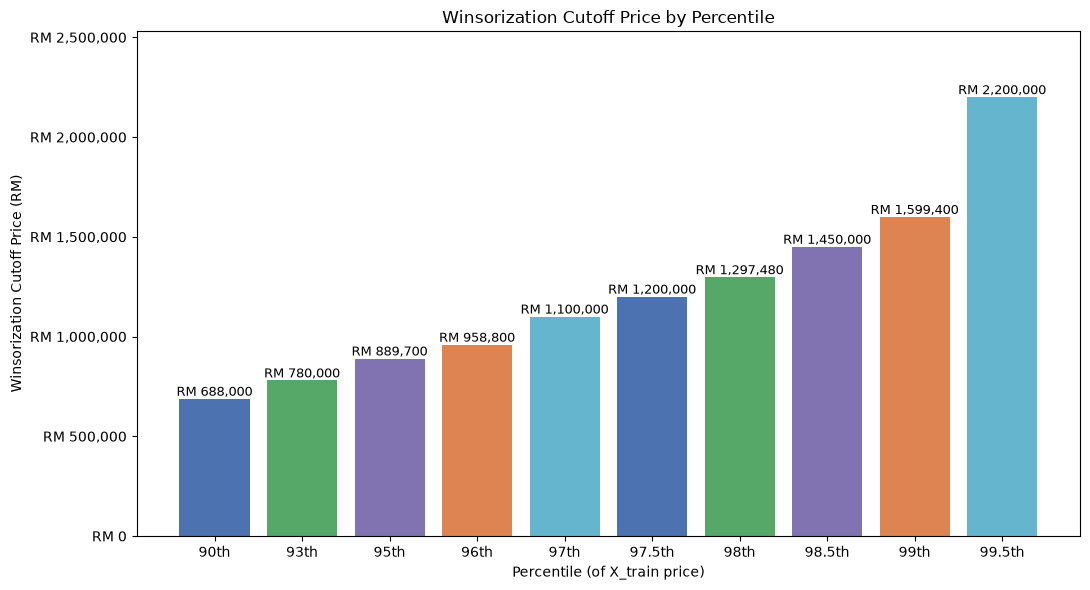

In [3]:
bar_colors = ["#4c72b0", "#55a868", "#8172b2", "#dd8452", "#64b5cd",
              "#4c72b0", "#55a868", "#8172b2", "#dd8452", "#64b5cd"]

fig, ax = plt.subplots(figsize=(11, 6))
labels = [f"{p}th" for p in percentiles]
bars = ax.bar(labels, scan_df["threshold_RM"], color=bar_colors)

ax.yaxis.set_major_formatter(rm_formatter)
for bar, val in zip(bars, scan_df["threshold_RM"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val, f"RM {val:,.0f}",
            ha="center", va="bottom", fontsize=9, rotation=0)

ax.set_xlabel("Percentile (of X_train price)")
ax.set_ylabel("Winsorization Cutoff Price (RM)")
ax.set_title("Winsorization Cutoff Price by Percentile")
ax.set_ylim(0, scan_df["threshold_RM"].max() * 1.15)
plt.tight_layout()
plt.show()


## 2. Winsorize Example: 97th Percentile

Threshold fit on `X_train` price only, then the same cutoff applied to `X_test`. Each model is retrained (existing tuned hyperparameters, reused via `clone()`) on the winsorized target, and compared against the uncapped baseline already reported in Section 5.2/6.1.

In [4]:
CAP_PERCENTILE = 0.97
threshold_97 = price_train.quantile(CAP_PERCENTILE)

price_train_capped = price_train.clip(upper=threshold_97)
price_test_capped = price_test.clip(upper=threshold_97)
n_train_capped = int((price_train > threshold_97).sum())
n_test_capped = int((price_test > threshold_97).sum())

y_train_capped = np.log(price_train_capped)
y_test_capped = np.log(price_test_capped)

print(f"Winsorize threshold (97th pct of X_train price): RM {threshold_97:,.0f}")
print(f"X_train rows capped: {n_train_capped} / {len(price_train)} ({n_train_capped/len(price_train)*100:.2f}%)")
print(f"X_test rows capped:  {n_test_capped} / {len(price_test)} ({n_test_capped/len(price_test)*100:.2f}%)")
print(f"New price range - train: RM {price_train_capped.min():,.0f} to RM {price_train_capped.max():,.0f}")
print(f"New price range - test:  RM {price_test_capped.min():,.0f} to RM {price_test_capped.max():,.0f}")


Winsorize threshold (97th pct of X_train price): RM 1,100,000
X_train rows capped: 88 / 3004 (2.93%)
X_test rows capped:  26 / 751 (3.46%)
New price range - train: RM 38,000 to RM 1,100,000
New price range - test:  RM 69,999 to RM 1,100,000


In [5]:
BASELINES = {
    "Linear Regression": {"test_rmse": 194976, "test_mae": 92466},
    "Ridge Regression":   {"test_rmse": 194977, "test_mae": 92466},
    "Random Forest":      {"test_rmse": 175825, "test_mae": 76856},
    "XGBoost":             {"test_rmse": 175439, "test_mae": 85848},
    "SVR":                 {"test_rmse": 195720, "test_mae": 88335},
    "KNN":                 {"test_rmse": 187823, "test_mae": 94442},
}

MODEL_FILES = {
    "Linear Regression": ("linear_model.pkl", "scaled"),
    "Ridge Regression": ("ridge_model.pkl", "scaled"),
    "Random Forest": ("random_forest_model.pkl", "raw"),
    "XGBoost": ("xgboost_model.pkl", "raw"),
    "SVR": ("svr_model.pkl", "scaled"),
    "KNN": ("knn_model.pkl", "scaled"),
}

fitted_models = {}
for name, (fname, data_type) in MODEL_FILES.items():
    path = os.path.join(MODEL_DIR, fname)
    fitted_models[name] = (joblib.load(path), data_type)
print(f"Loaded {len(fitted_models)} models: {list(fitted_models.keys())}")


Loaded 6 models: ['Linear Regression', 'Ridge Regression', 'Random Forest', 'XGBoost', 'SVR', 'KNN']


In [6]:
results_97 = {}

for name, (fitted, data_type) in fitted_models.items():
    fresh = clone(fitted)
    X_train = X_train_raw if data_type == "raw" else X_train_scaled
    X_test = X_test_raw if data_type == "raw" else X_test_scaled

    fresh.fit(X_train, y_train_capped)
    test_m = evaluate_model(fresh, X_test, y_test_capped)

    base = BASELINES[name]
    results_97[name] = {
        "Test RMSE (baseline)": base["test_rmse"], "Test RMSE (97th capped)": test_m["RMSE"],
        "Test MAE (baseline)": base["test_mae"], "Test MAE (97th capped)": test_m["MAE"],
    }

results_97_df = pd.DataFrame(results_97).T
results_97_df


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,Test RMSE (baseline),Test RMSE (97th capped),Test MAE (baseline),Test MAE (97th capped)
Linear Regression,194976.0,117888.188984,92466.0,76958.303918
Ridge Regression,194977.0,117888.077351,92466.0,76958.223518
Random Forest,175825.0,98038.376960,76856.0,61792.600257
XGBoost,175439.0,100440.171594,85848.0,67830.932423
SVR,195720.0,114590.887587,88335.0,75862.582086
KNN,187823.0,125879.625498,94442.0,80531.251863


## 3. Test RMSE vs Winsorization Cutoff

Repeats the winsorize experiment at 90th, 93rd, 95th, 97th, and 99th percentiles to show how Test RMSE changes as more of the price tail is capped.

In [7]:
PERCENTILES = [90, 93, 95, 97, 99]
sweep_results = {name: [] for name in fitted_models}
sweep_thresholds = []

for pct in PERCENTILES:
    threshold = price_train.quantile(pct / 100)
    sweep_thresholds.append(threshold)
    price_train_c = price_train.clip(upper=threshold)
    price_test_c = price_test.clip(upper=threshold)
    y_train_c = np.log(price_train_c)
    y_test_c = np.log(price_test_c)

    for name, (fitted, data_type) in fitted_models.items():
        fresh = clone(fitted)
        X_train = X_train_raw if data_type == "raw" else X_train_scaled
        X_test = X_test_raw if data_type == "raw" else X_test_scaled
        fresh.fit(X_train, y_train_c)
        test_m = evaluate_model(fresh, X_test, y_test_c)
        sweep_results[name].append(test_m["RMSE"])
    print(f"{pct}th percentile (RM {threshold:,.0f}) done")

print("\nSweep complete.")


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


90th percentile (RM 688,000) done


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


93th percentile (RM 780,000) done


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


95th percentile (RM 889,700) done


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


97th percentile (RM 1,100,000) done


C:\Users\Low\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


99th percentile (RM 1,599,400) done

Sweep complete.


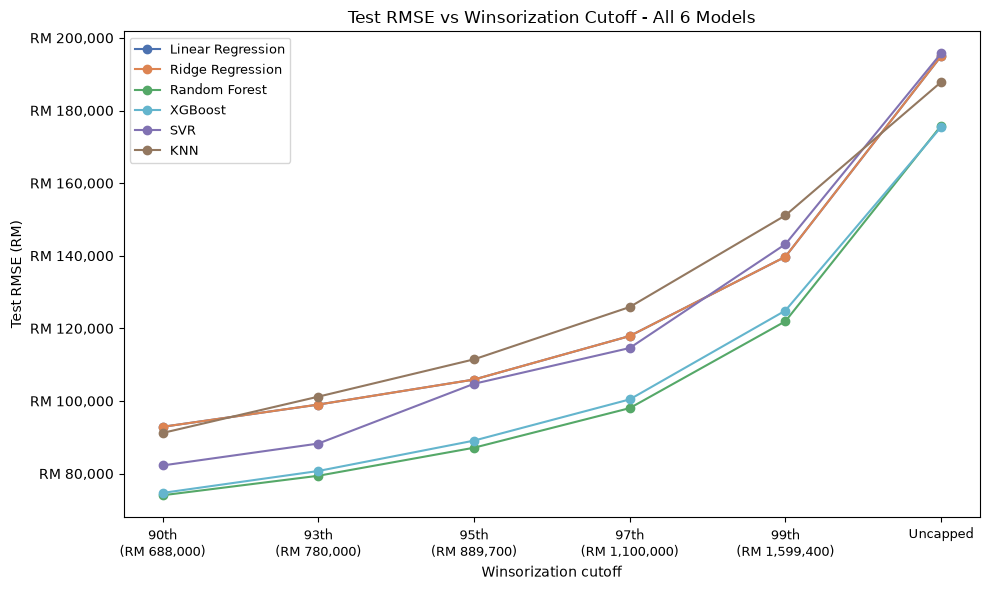

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
x_labels = [f"{p}th\n(RM {t:,.0f})" for p, t in zip(PERCENTILES, sweep_thresholds)] + ["Uncapped"]
line_colors = ["#4c72b0", "#dd8452", "#55a868", "#64b5cd", "#8172b2", "#937860"]

for (name, values), color in zip(sweep_results.items(), line_colors):
    full_values = values + [BASELINES[name]["test_rmse"]]
    ax.plot(range(len(x_labels)), full_values, marker="o", label=name, color=color)

ax.yaxis.set_major_formatter(rm_formatter)
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_xlabel("Winsorization cutoff")
ax.set_ylabel("Test RMSE (RM)")
ax.set_title("Test RMSE vs Winsorization Cutoff - All 6 Models")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [9]:
sweep_table = pd.DataFrame(sweep_results, index=[f"{p}th pct" for p in PERCENTILES])
sweep_table.loc["Uncapped"] = [BASELINES[name]["test_rmse"] for name in sweep_results]
sweep_table


,Linear Regression,Ridge Regression,Random Forest,XGBoost,SVR,KNN
90th pct,92889.388575,92889.202128,74039.377263,74687.291748,82251.507972,91196.987152
93th pct,99015.902339,99015.710025,79412.579541,80726.276526,88280.114495,101195.276281
95th pct,105909.035316,105908.857621,87133.466948,89091.933860,104739.945734,111470.372065
97th pct,117888.188984,117888.077351,98038.376960,100440.171594,114590.887587,125879.625498
99th pct,139725.433372,139725.551622,121949.887416,124901.486465,143180.710473,151110.849240
Uncapped,194976.000000,194977.000000,175825.000000,175439.000000,195720.000000,187823.000000
